### Pacotes importados

In [1]:
import Pkg
Pkg.add("Plots")

using Plots
using LinearAlgebra

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Manifest.toml`


## Chapter 9: Quadratic problems

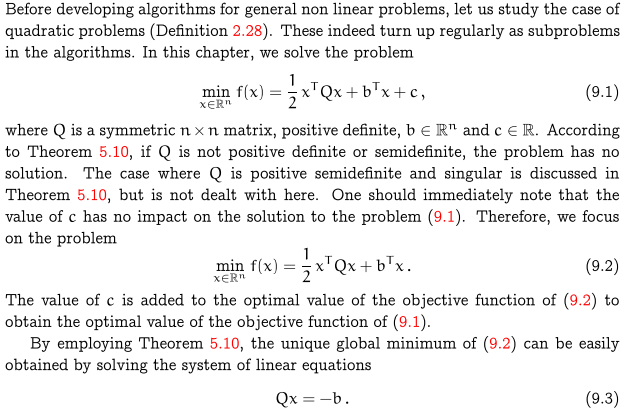

### Algorithm 9.1: quadratic problems: direct solution

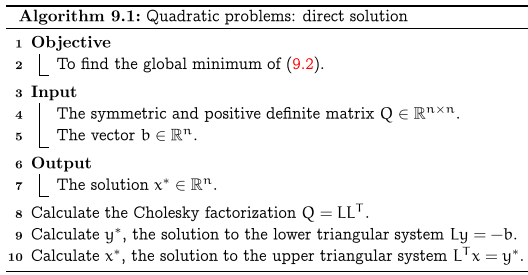

Example 9.8: $Q=\left(\begin{array}{cccc} 1& 1 & 1 & 1 \\ 1 & 2 & 2 & 2 \\ 1 & 2 & 3 & 3 \\ 1 & 2 & 3 & 4\end{array}\right)$, $b=\left(\begin{array}{c}-4 \\ -7 \\ -9 \\ -10\end{array}\right)$. First, confirm Q is P.D.

In [6]:
function quadratic_solver(Q, b)
    # Fatoração de Cholesky: Q = L * L'
    L = cholesky(Q).L

    # Resolve L y = -b
    y = L \ (-b)

    # Resolve L' x = y
    x = L' \ y

    return x
end




quadratic_solver (generic function with 1 method)

In [7]:
Q = [
    1.0 1 1 1;
    1 2 2 2;
    1 2 3 3;
    1 2 3 4
]

b = [-4.0, -7, -9, -10]

x = quadratic_solver(Q, b)

println("Solução x*: ", x)

# Verificação: Qx ≈ -b
println("Qx: ", Q*x)
println("-b: ", -b)

Solução x*: [1.0, 1.0, 1.0, 1.0]
Qx: [4.0, 7.0, 9.0, 10.0]
-b: [4.0, 7.0, 9.0, 10.0]


### Algorithm 9.2: Conjugate gradient method

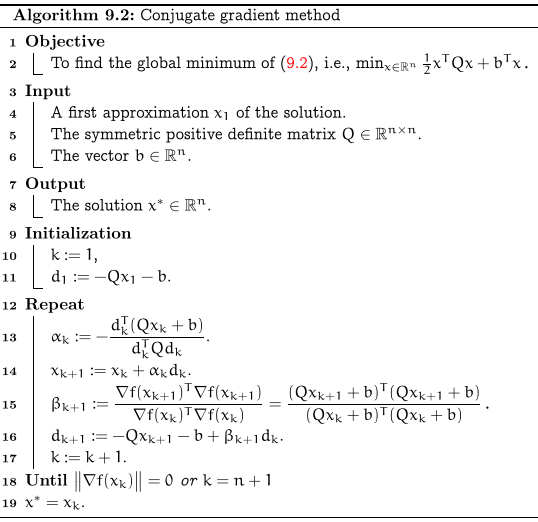

Run the algorithm from $x_0=\left(\begin{array}{c}5 \\ 5 \\ 5 \\ 5 \end{array}\right)$.

In [9]:
function gradiente_conjugado_plot(Q, b, x0; max_iter=100)
    x = copy(x0)

    g = Q*x + b
    d = -g

    xs = [copy(x)]
    erros = [norm(g)]

    k = 1

    while norm(g) > 1e-12 && k ≤ max_iter
        α = -(d' * g) / (d' * Q * d)

        x = x + α * d

        g_new = Q*x + b

        β = (g_new' * g_new) / (g' * g)

        d = -g_new + β * d

        g = g_new

        push!(xs, copy(x))
        push!(erros, norm(g))

        k += 1
    end

    return x, xs, erros, k-1
end


function plot_gradiente_conjugado(Q, b, x0; titulo="Gradiente Conjugado")
    x_aprox, xs, erros, iter = gradiente_conjugado_plot(Q, b, x0)

    k_vals = 0:length(xs)-1
    x1_vals = [x[1] for x in xs]
    x2_vals = [x[2] for x in xs]

    println("Solução aproximada: ", x_aprox)
    println("Iterações: ", iter)
    println("Norma do gradiente final: ", erros[end])

    p1 = plot(
        k_vals,
        x1_vals,
        marker=:circle,
        linewidth=2,
        xlabel="Iteração",
        ylabel="Valor",
        title="Convergência - $titulo",
        label="x₁"
    )

    plot!(
        p1,
        k_vals,
        x2_vals,
        marker=:diamond,
        linewidth=2,
        label="x₂"
    )

    p2 = plot(
        k_vals,
        erros,
        marker=:circle,
        linewidth=2,
        yscale=:log10,
        xlabel="Iteração",
        ylabel="||∇f(xₖ)||",
        title="Erro - $titulo",
        label="Gradiente"
    )

    display(p1)
    display(p2)

    return x_aprox, iter
end

plot_gradiente_conjugado (generic function with 1 method)

Solução aproximada: [1.0, 1.0000000000000013, 0.9999999999999984, 1.0000000000000004]
Iterações: 5
Norma do gradiente final: 8.881784197001252e-16


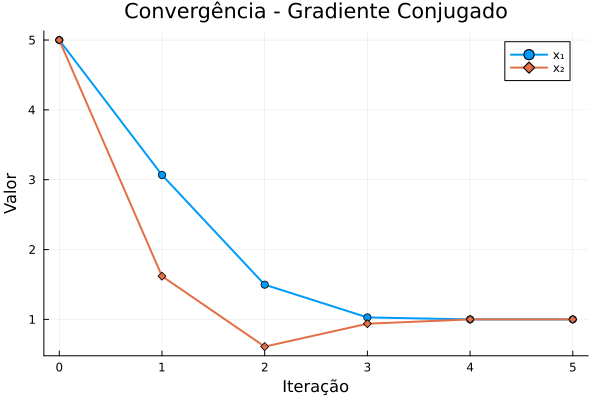

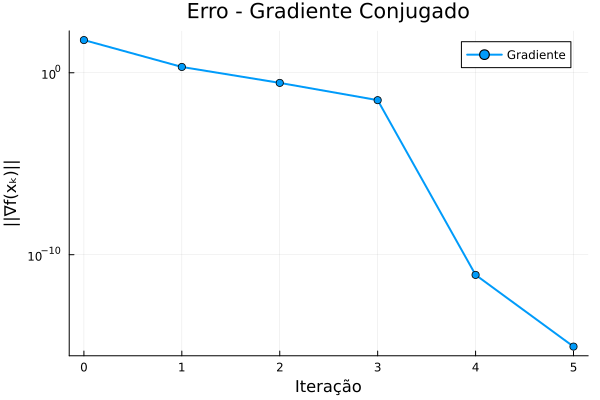

([1.0, 1.0000000000000013, 0.9999999999999984, 1.0000000000000004], 5)

In [10]:
Q = [
    1.0 1 1 1;
    1 2 2 2;
    1 2 3 3;
    1 2 3 4
]

b = [-4.0, -7, -9, -10]

x0 = [5.0, 5.0, 5.0, 5.0]

plot_gradiente_conjugado(Q, b, x0)

An error is triggered if the matrix is not definite positive. Here, $Q=\left(\begin{array}{cccc} 1& 2 & 3 & 4 \\ 5 & 6 & 7 & 8 \\ 9 & 10 & 11 & 12 \\ 13 & 14 & 15 & 16\end{array}\right)$

Solução aproximada: [-6.0941034668322e17, 6.094103498794505e17, 6.094103501896868e17, -6.094103457546085e17]
Iterações: 100
Norma do gradiente final: 1.493395880075136e11


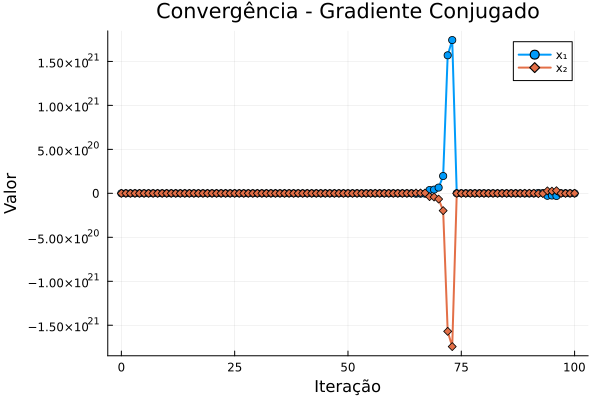

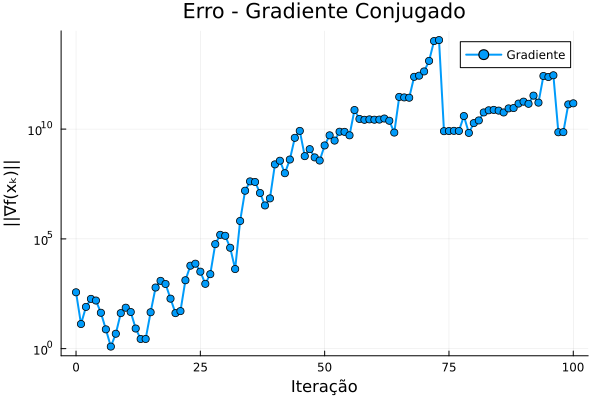

([-6.0941034668322e17, 6.094103498794505e17, 6.094103501896868e17, -6.094103457546085e17], 100)

In [11]:
Q = [
    1.0 2 3 4;
    5 6 7 8;
    9 10 11 12;
    13 14 15 16
]

b = [-4.0, -7, -9, -10]

x0 = [5.0, 5.0, 5.0, 5.0]

plot_gradiente_conjugado(Q, b, x0)